In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Plot styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [4]:
df.head()
df.tail()
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


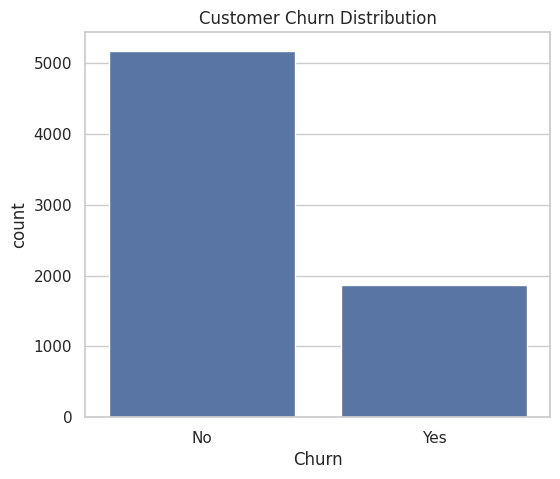

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

In [11]:
(df["Churn"].value_counts(normalize=True)*100).round(2)

,proportion
Churn,
No,73.46
Yes,26.54


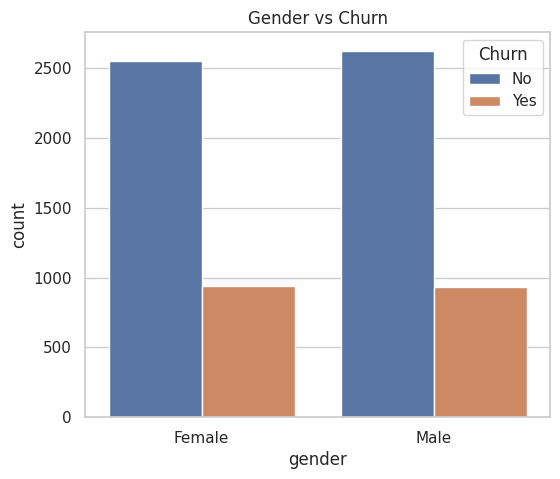

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="gender",
              hue="Churn")

plt.title("Gender vs Churn")

plt.show()

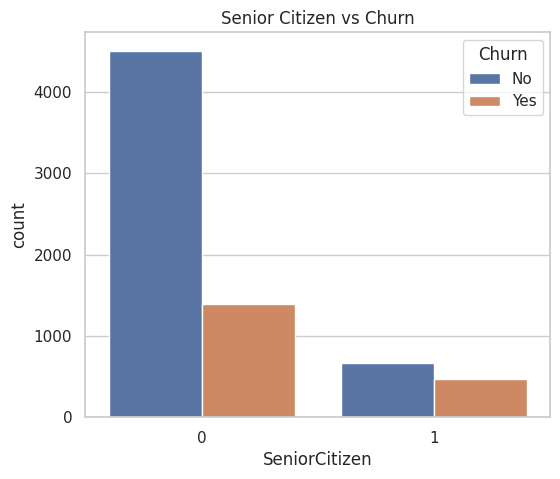

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="SeniorCitizen",
              hue="Churn")

plt.title("Senior Citizen vs Churn")

plt.show()

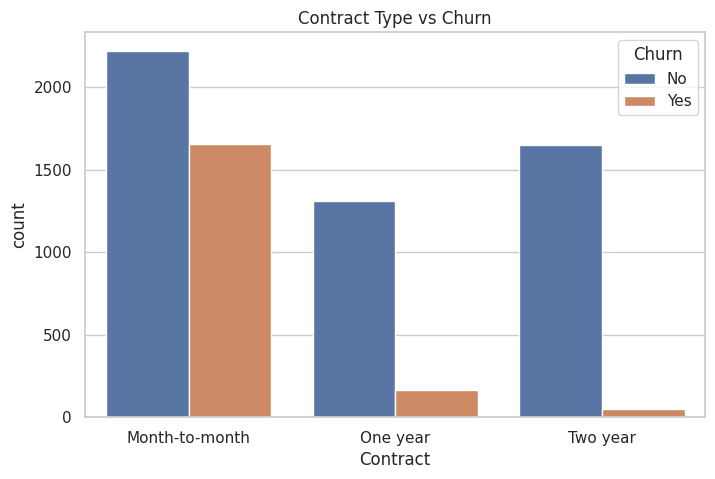

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Contract",
              hue="Churn")

plt.title("Contract Type vs Churn")

plt.show()

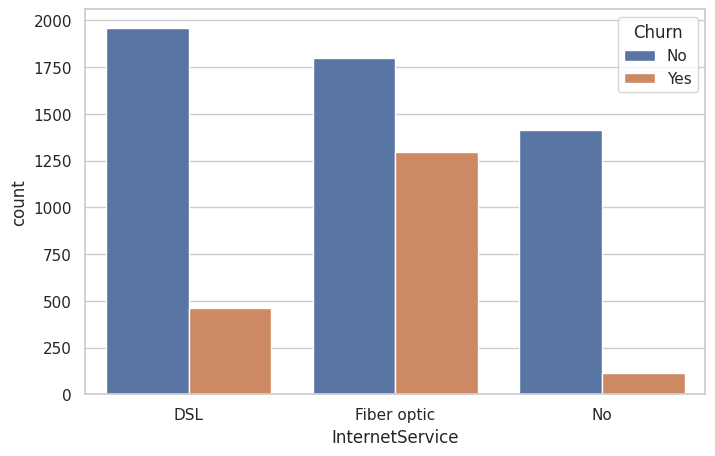

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="InternetService",
              hue="Churn")

plt.show()

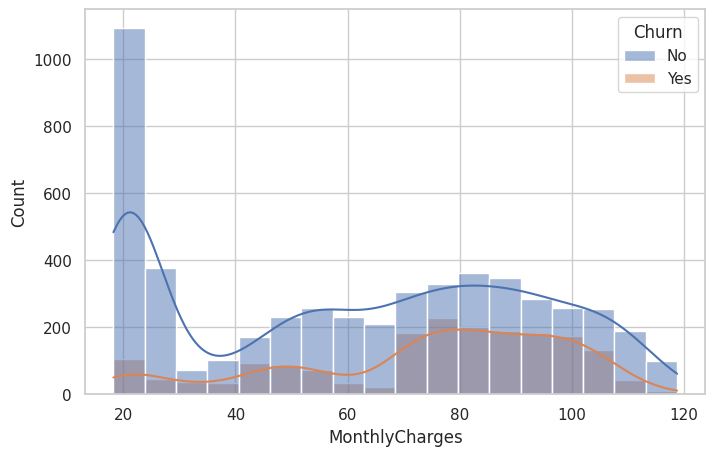

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,
             x="MonthlyCharges",
             hue="Churn",
             kde=True)

plt.show()

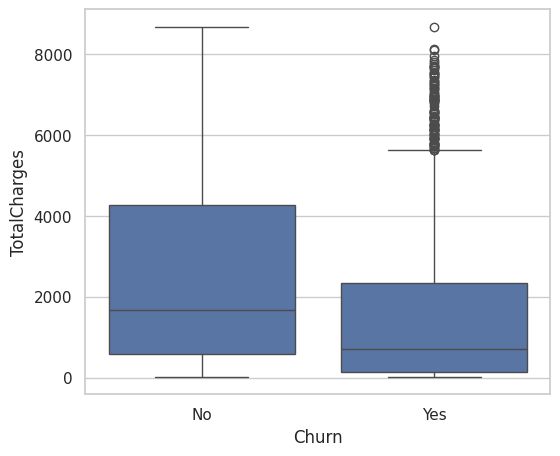

In [17]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df,
            x="Churn",
            y="TotalCharges")

plt.show()

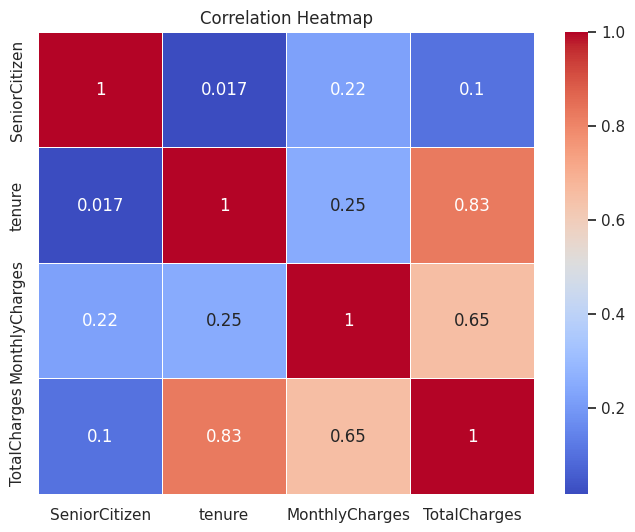

In [18]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

contract.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [20]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [21]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [24]:
print("""
Conclusion

The analysis identified several important factors contributing to customer churn.
Customers with month-to-month contracts, higher monthly charges, fiber optic internet,
and electronic check payments exhibit significantly higher churn rates.
Long-term contracts and longer customer tenure are associated with better retention.
Businesses can reduce churn by targeting high-risk customers with personalized offers,
improved customer support, and incentives for long-term subscriptions.
""")


Conclusion

The analysis identified several important factors contributing to customer churn.
Customers with month-to-month contracts, higher monthly charges, fiber optic internet,
and electronic check payments exhibit significantly higher churn rates.
Long-term contracts and longer customer tenure are associated with better retention.
Businesses can reduce churn by targeting high-risk customers with personalized offers,
improved customer support, and incentives for long-term subscriptions.



In [25]:
recommendations = [
    "Offer discounts on yearly contracts.",
    "Improve Fiber Optic service quality.",
    "Target new customers with onboarding offers.",
    "Provide loyalty rewards for long-term customers.",
    "Offer customized retention plans for high monthly charge customers."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Offer discounts on yearly contracts.
2. Improve Fiber Optic service quality.
3. Target new customers with onboarding offers.
4. Provide loyalty rewards for long-term customers.
5. Offer customized retention plans for high monthly charge customers.
